In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/marketing_campaign_dataset.csv")

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [5]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [6]:
df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Campaign_ID,0,0.0
Company,0,0.0
Campaign_Type,0,0.0
Target_Audience,0,0.0
Duration,0,0.0
Channel_Used,0,0.0
Conversion_Rate,0,0.0
Acquisition_Cost,0,0.0
ROI,0,0.0
Location,0,0.0


In [7]:
df.duplicated().sum()

df = df.drop_duplicates()

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  str           
 2   Campaign_Type     200000 non-null  str           
 3   Target_Audience   200000 non-null  str           
 4   Duration          200000 non-null  str           
 5   Channel_Used      200000 non-null  str           
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  str           
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  str           
 10  Language          200000 non-null  str           
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Customer_Segmen

In [9]:
for col in [
    "Company",
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Location",
    "Language",
    "Customer_Segment"
]:
    print(f"\n{col}")
    print(df[col].unique())


Company
<ArrowStringArray>
['Innovate Industries',      'NexGen Systems',   'Alpha Innovations',
  'DataTech Solutions',            'TechCorp']
Length: 5, dtype: str

Campaign_Type
<ArrowStringArray>
['Email', 'Influencer', 'Display', 'Search', 'Social Media']
Length: 5, dtype: str

Target_Audience
<ArrowStringArray>
['Men 18-24', 'Women 35-44', 'Men 25-34', 'All Ages', 'Women 25-34']
Length: 5, dtype: str

Channel_Used
<ArrowStringArray>
['Google Ads', 'YouTube', 'Instagram', 'Website', 'Facebook', 'Email']
Length: 6, dtype: str

Location
<ArrowStringArray>
['Chicago', 'New York', 'Los Angeles', 'Miami', 'Houston']
Length: 5, dtype: str

Language
<ArrowStringArray>
['Spanish', 'German', 'French', 'Mandarin', 'English']
Length: 5, dtype: str

Customer_Segment
<ArrowStringArray>
[  'Health & Wellness',        'Fashionistas', 'Outdoor Adventurers',
             'Foodies',    'Tech Enthusiasts']
Length: 5, dtype: str


In [10]:
import os

os.makedirs("../cleaned_data", exist_ok=True)

df.to_csv("../cleaned_data/marketing_campaign_dataset_cleaned.csv", index=False)

In [11]:
df.dtypes

df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  str           
 2   Campaign_Type     200000 non-null  str           
 3   Target_Audience   200000 non-null  str           
 4   Duration          200000 non-null  str           
 5   Channel_Used      200000 non-null  str           
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  str           
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  str           
 10  Language          200000 non-null  str           
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Customer_Segmen

In [12]:
numerical_columns = [
    "Conversion_Rate",
    "Acquisition_Cost",
    "ROI",
    "Clicks",
    "Impressions",
    "Engagement_Score"
]

df[numerical_columns].describe()

,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.080070,5.002438,549.772030,5507.301520,5.494710
std,0.040602,1.734488,260.019056,2596.864286,2.872581
min,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,0.120000,6.510000,775.000000,7753.000000,8.000000
max,0.150000,8.000000,1000.000000,10000.000000,10.000000


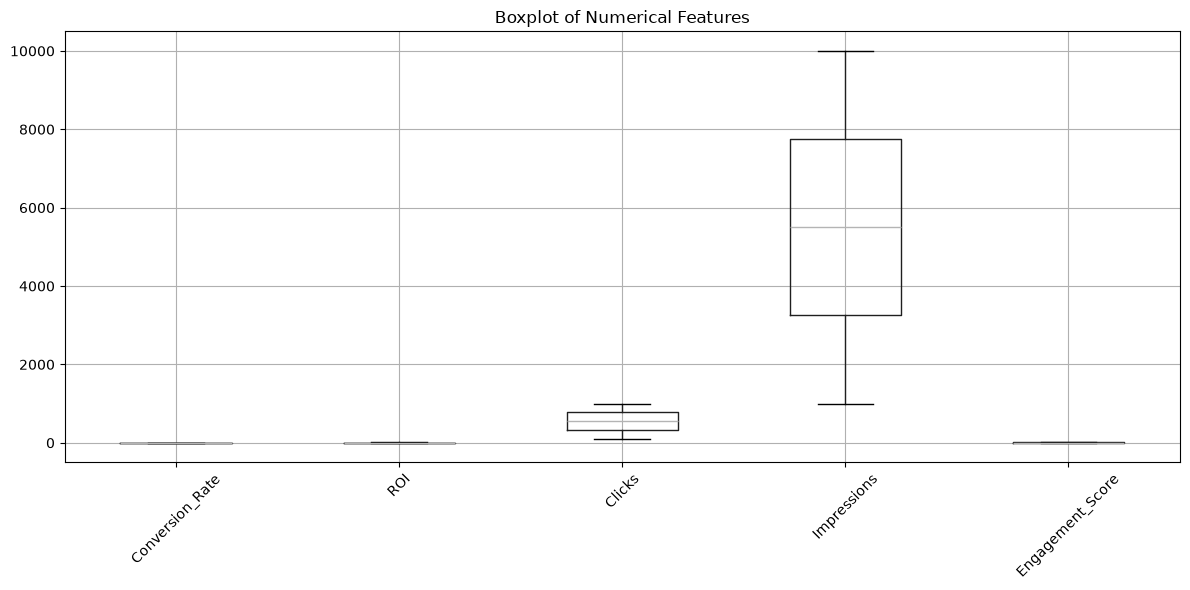

In [13]:



plt.figure(figsize=(12,6))
df[numerical_columns].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.tight_layout()
plt.savefig("../images/boxplot_numerical_features.png")
plt.show()

In [15]:
categorical_columns = [
    "Company",
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Location",
    "Language",
    "Customer_Segment"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Company
Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64

Campaign_Type
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

Target_Audience
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64

Channel_Used
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64

Location
Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64

Language
Language
Mandarin    40255
Spanish     40102
German      39983
English     39896
French      39764
Name: count, dtype: int64

Customer_Segment
Custome

In [16]:
categorical_columns = [
    "Company",
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Location",
    "Language",
    "Customer_Segment"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Company
Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64

Campaign_Type
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

Target_Audience
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64

Channel_Used
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64

Location
Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64

Language
Language
Mandarin    40255
Spanish     40102
German      39983
English     39896
French      39764
Name: count, dtype: int64

Customer_Segment
Custome

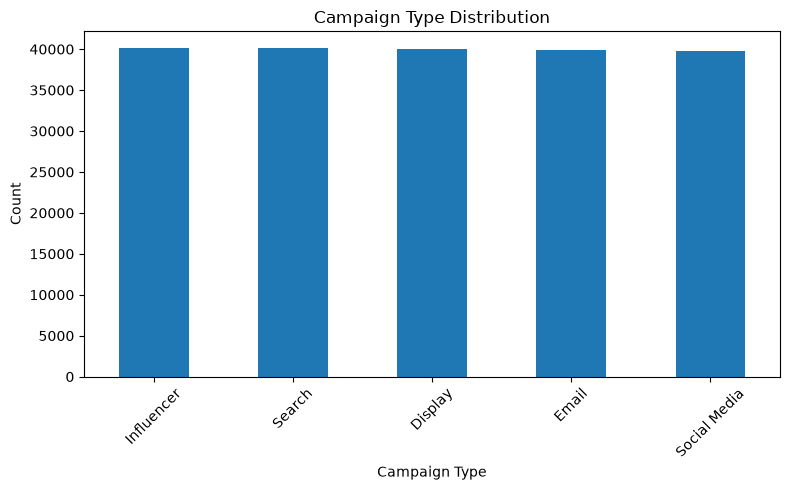

In [17]:
import matplotlib.pyplot as plt

campaign_counts = df["Campaign_Type"].value_counts()

plt.figure(figsize=(8,5))
campaign_counts.plot(kind="bar")
plt.title("Campaign Type Distribution")
plt.xlabel("Campaign Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/campaign_type_distribution.png")
plt.show()

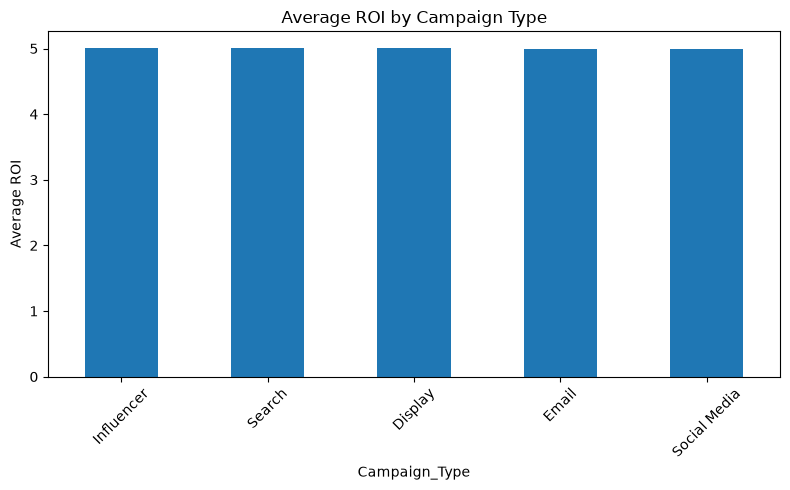

In [18]:
roi_campaign = df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
roi_campaign.plot(kind="bar")
plt.title("Average ROI by Campaign Type")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/roi_by_campaign_type.png")
plt.show()

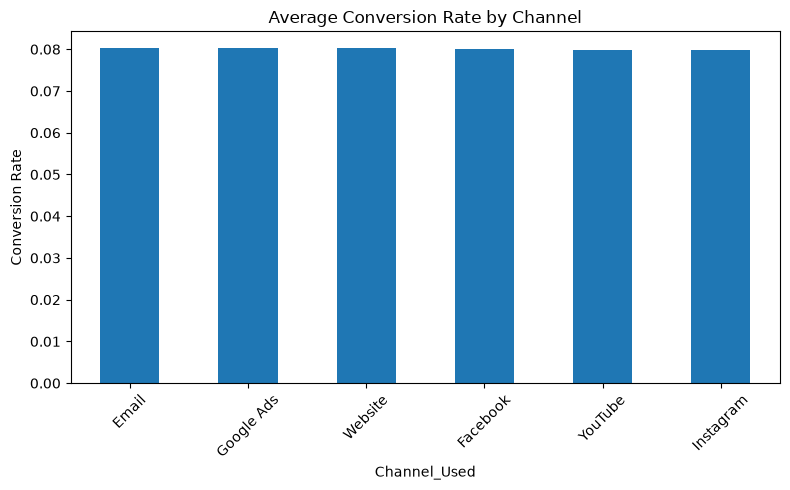

In [19]:
conversion = df.groupby("Channel_Used")["Conversion_Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
conversion.plot(kind="bar")
plt.title("Average Conversion Rate by Channel")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/conversion_by_channel.png")
plt.show()

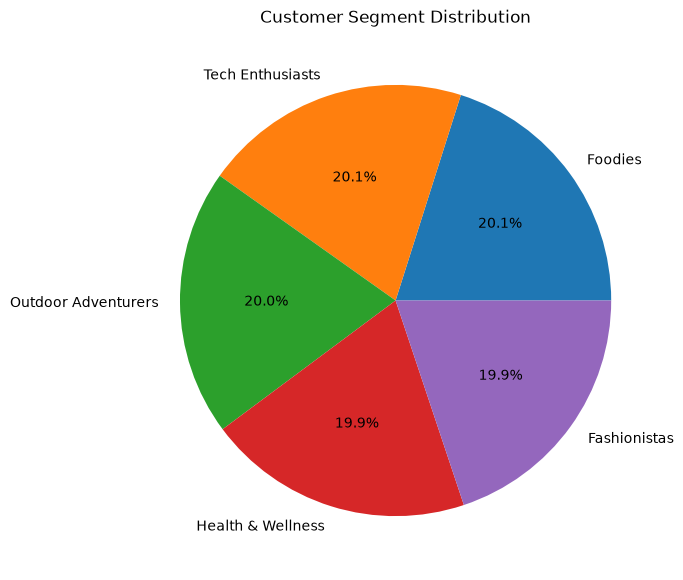

In [20]:
segment = df["Customer_Segment"].value_counts()

plt.figure(figsize=(7,7))
segment.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Customer Segment Distribution")

plt.savefig("../images/customer_segments.png")
plt.show()

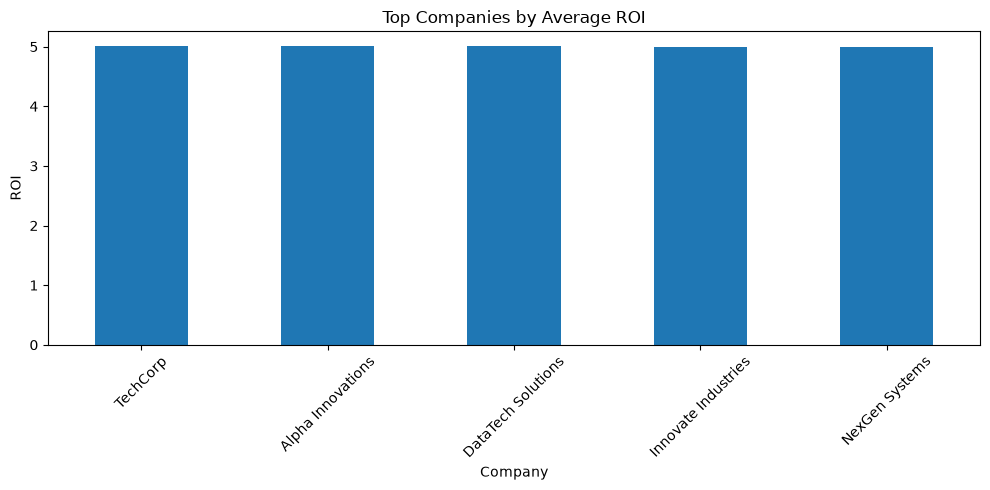

In [21]:
company = df.groupby("Company")["ROI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
company.plot(kind="bar")

plt.title("Top Companies by Average ROI")
plt.ylabel("ROI")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/top_companies_roi.png")
plt.show()

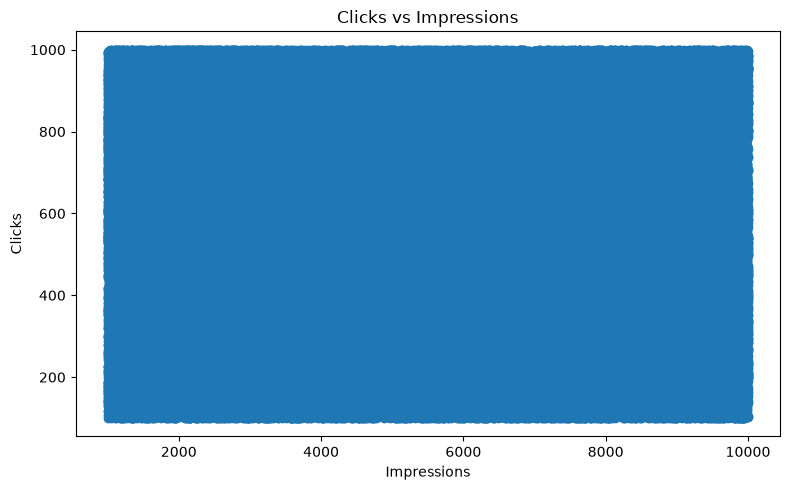

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["Impressions"], df["Clicks"])

plt.title("Clicks vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Clicks")

plt.tight_layout()

plt.savefig("../images/clicks_vs_impressions.png")

plt.show()

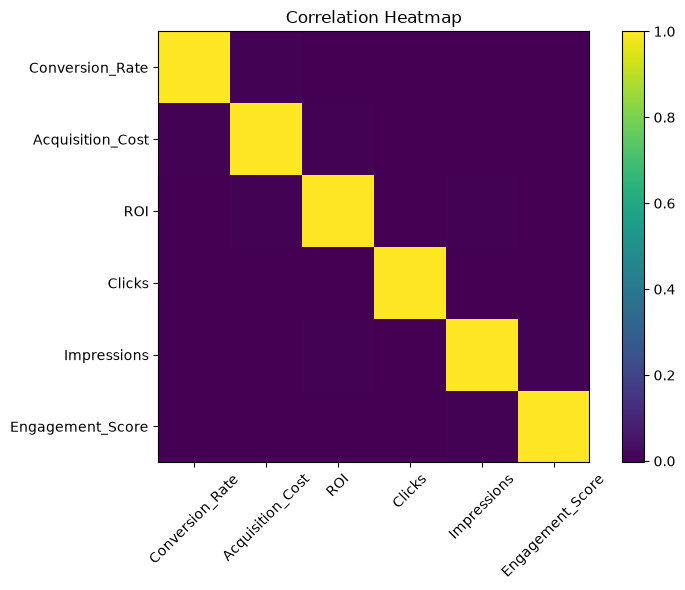

In [29]:
# clean monetary column and compute correlation matrix
df["Acquisition_Cost"] = df["Acquisition_Cost"].replace(r'[\$,]', '', regex=True).astype(float)

corr = df[[
    "Conversion_Rate",
    "Acquisition_Cost",
    "ROI",
    "Clicks",
    "Impressions",
    "Engagement_Score"
]].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../images/correlation_heatmap.png")

plt.show()

In [27]:
df["Acquisition_Cost"].head(10)

0    $16,174.00
1    $11,566.00
2    $10,200.00
3    $12,724.00
4    $16,452.00
5     $9,716.00
6    $11,067.00
7    $13,280.00
8    $18,066.00
9    $13,766.00
Name: Acquisition_Cost, dtype: str